# Capstone Project Machine Learning - OPREC Neo Telemetri 2026
**Nama:** Ahmad Fathi
**Tema:** Klasifikasi Gambar untuk (Klasifikasi Cuaca Multi-kelas)
**Dataset:** pratik2901/multiclass-weather-dataset (Kaggle)

## Langkah 1: Environment Setup & Download Dataset
Pada tahap ini, kita melakukan instalasi dan import library yang dibutuhkan. Selain itu, kita mengintegrasikan API Kaggle untuk mengunduh dataset secara langsung ke dalam environment Google Colab.

In [ ]:
# Import library
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import kagglehub
from google.colab import userdata

# 2. Mengunci Seed untuk Reproduksibilitas
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

# 3. Konfigurasi Kredensial API Kaggle

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')

# 3. Download Dataset
path = kagglehub.dataset_download("pratik2901/multiclass-weather-dataset")
dataset_dir = Path(path)
print("Dataset siap digunakan di:", dataset_dir)

Autentikasi Kaggle berhasil dikonfigurasi secara aman!
Using Colab cache for faster access to the 'multiclass-weather-dataset' dataset.
Dataset siap digunakan di: /kaggle/input/multiclass-weather-dataset


In [ ]:
print(os.listdir(path))

['Multi-class Weather Dataset']


##  Data Exploration & Pemetaan Struktur Dataset
Setelah dataset diunduh, kita melakukan eksplorasi data (EDA) dengan mengumpulkan seluruh path gambar (`.jpg`, `.jpeg`, `.png`) dan menyusunnya ke dalam `DataFrame` Pandas. Label cuaca diambil otomatis dari nama folder masing-masing gambar.

Dari tabel ini kita bisa cek total sampel data dan melihat apakah ada *class imbalance* yang bisa memengaruhi performa model.

In [ ]:
import pandas as pd

# Kumpulkan semua path gambar
image_extensions = ["*.jpg", "*.jpeg", "*.png"]
all_images = []

for extension in image_extensions:
    all_images.extend(dataset_dir.rglob(extension))

# Susun ke DataFrame, label diambil dari nama folder
df_dataset = pd.DataFrame({
    'image_path': [str(image) for image in all_images],
    'label': [image.parent.name for image in all_images]
})

print(f"TOTAL GAMBAR YANG DITEMUKAN: {len(df_dataset)}")



TOTAL GAMBAR YANG DITEMUKAN: 1125


#Visualisasikan distribusi kelas menggunakan Bar chart

label
Sunrise    357
Cloudy     300
Shine      253
Rain       215
Name: count, dtype: int64


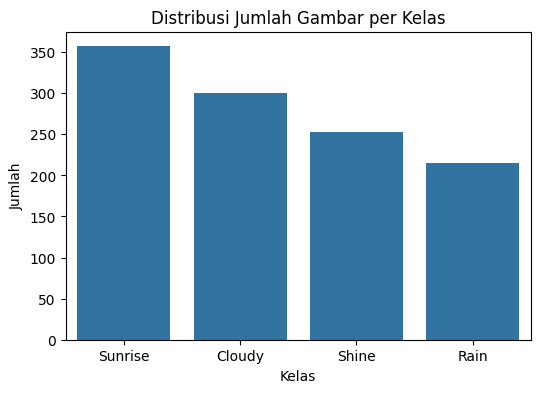

In [ ]:
import seaborn as sns

# Hitung jumlah gambar per kelas
class_counts = df_dataset['label'].value_counts()
print(class_counts)

# Visualisasi distribusi kelas
plt.figure(figsize=(6,4))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

## Dataset Splitting (Pembagian Data)
Dataset dibagi menjadi tiga bagian: **Training (80%)**, **Validation (10%)**, dan **Test (10%)** menggunakan *Stratified Splitting* dari Scikit-Learn (`train_test_split`).

Metode ini menjaga proporsi kelas cuaca tetap seimbang di setiap subset, sehingga evaluasi model (akurasi, precision, recall, F1-score) lebih objektif.

In [ ]:
from sklearn.model_selection import train_test_split

# Bagi data jadi Training (80%) dan Sisa (20%)
df_train, df_rem = train_test_split(
    df_dataset,
    train_size=0.8,
    random_state=0,
    stratify=df_dataset['label']
)

# Bagi Sisa menjadi Validation (10%) dan Test (10%)
df_val, df_test = train_test_split(
    df_rem,
    test_size=0.5,
    random_state=0,
    stratify=df_rem['label']
)

# Verifikasi hasil pembagian
print(f"Jumlah Data Training   : {len(df_train)} gambar ({len(df_train)/len(df_dataset)*100:.0f}%)")
print(f"Jumlah Data Validation : {len(df_val)} gambar ({len(df_val)/len(df_dataset)*100:.0f}%)")
print(f"Jumlah Data Test       : {len(df_test)} gambar ({len(df_test)/len(df_dataset)*100:.0f}%)")

# Cek proporsi kelas di tiap subset
print("\nProporsi Kelas di Data Training (%):")
print((df_train['label'].value_counts(normalize=True) * 100).round(2))

print("\nProporsi Kelas di Data Validation (%):")
print((df_val['label'].value_counts(normalize=True) * 100).round(2))

Jumlah Data Training   : 900 gambar (80%)
Jumlah Data Validation : 112 gambar (10%)
Jumlah Data Test       : 113 gambar (10%)

Proporsi Kelas di Data Training (%):
label
Sunrise    31.78
Cloudy     26.67
Shine      22.44
Rain       19.11
Name: proportion, dtype: float64

Proporsi Kelas di Data Validation (%):
label
Sunrise    31.25
Cloudy     26.79
Shine      22.32
Rain       19.64
Name: proportion, dtype: float64


## Preprocessing & Data Augmentation (Data Loader)
Pada tahap ini, kita memproses gambar mentah agar siap dimasukkan ke dalam arsitektur CNN:
1. **Normalisasi (Rescaling):** Mengubah nilai piksel gambar dari rentang [0-255] menjadi [0-1] dengan membaginya dengan 255.0 agar konvergensi gradient saat training lebih stabil.
2. **Resize:** Mengubah resolusi seluruh gambar menjadi dimensi seragam yaitu 150x150 piksel.
3. **Augmentasi Data (Khusus Data Training):** Menerapkan manipulasi gambar secara acak (rotasi, pergeseran, pemotongan zoom, dan pembalikan horizontal) untuk memperkaya variasi data latihan. Teknik ini sangat krusial untuk mencegah model mengalami *overfitting* dan meningkatkan kemampuan generalisasi model pada kondisi nyata (real-world).
4. **Data Loader:** Memanfaatkan `ImageDataGenerator.flow_from_dataframe` untuk mengalirkan data secara efisien dalam bentuk *batch* (ukuran 32) langsung dari jalur file yang ada di DataFrame Pandas.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Augmentasi khusus data training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Data validation & test cuma di-rescale, tanpa augmentasi
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Data loader dari DataFrame
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=0
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Mapping indeks kelas ke nama cuaca
class_indices = train_generator.class_indices
labels_map = {v: k for k, v in class_indices.items()}
print(labels_map)

Memuat Data Training...
Found 900 validated image filenames belonging to 4 classes.

Memuat Data Validation...
Found 112 validated image filenames belonging to 4 classes.

 Memuat Data Test...
Found 113 validated image filenames belonging to 4 classes.

Mapping Indeks Kelas ke Nama Cuaca:
{0: 'Cloudy', 1: 'Rain', 2: 'Shine', 3: 'Sunrise'}


## Perancangan Arsitektur CNN Standar (Custom CNN)
Pada tahap ini, kita membangun arsitektur CNN sendiri dari nol secara sekuensial yang lebih sederhana dan mudah dipahami. Model ini terdiri dari beberapa blok Conv2D untuk ekstraksi fitur visual gambar, MaxPooling2D untuk reduksi dimensi spasial, serta lapisan Flatten dan Dense untuk melakukan klasifikasi akhir ke dalam kelas-kelas cuaca berdasarkan probabilitas tertinggi.

In [ ]:
from tensorflow.keras import models, layers

num_classes = len(class_indices)

model = models.Sequential([
    # Blok 1: fitur dasar
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D((2, 2)),

    # Blok 2: fitur lebih kompleks
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Ubah matriks gambar jadi vektor 1D
    layers.Flatten(),

    # Klasifikasi akhir
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,308,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,328,132 (20.33 MB)

 Trainable params: 5,328,132 (20.33 MB)

 Non-trainable params: 0 (0.00 B)

##  Pelatihan Model (Training)
Kita melakukan proses pelatihan (*training*) pada model CNN kustom yang telah dibuat selama 10 epoch. Pada setiap epoch, kita dapat memantau perkembangan nilai akurasi (*accuracy*) dan kerugian (*loss*) baik pada data training maupun data validasi secara langsung.

In [ ]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    verbose=1
)

Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6456 - loss: 1.1820 - val_accuracy: 0.8125 - val_loss: 0.5035
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.8111 - loss: 0.5531 - val_accuracy: 0.8571 - val_loss: 0.4389
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8178 - loss: 0.5074 - val_accuracy: 0.9018 - val_loss: 0.3365
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8267 - loss: 0.4506 - val_accuracy: 0.8839 - val_loss: 0.3227
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8578 - loss: 0.3848 - val_accuracy: 0.9018 - val_loss: 0.2857
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.8678 - loss: 0.3732 - val_accuracy: 0.8661 - val_loss: 0.3272
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.8556 - loss: 0.3899 - val_accuracy: 0.8750 - val_loss: 0.3203
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.8444 - loss: 0.3886 - val_accuracy: 0.9375 - val_loss:

## Visualisasi Riwayat Training
Untuk mengevaluasi proses belajar model, kita memvisualisasikan grafik *accuracy* dan *loss* dari data training dan validasi di setiap epoch. Grafik ini membantu kita mendeteksi apakah model mengalami *overfitting* (akurasi training tinggi tapi validasi rendah) atau *underfitting*.

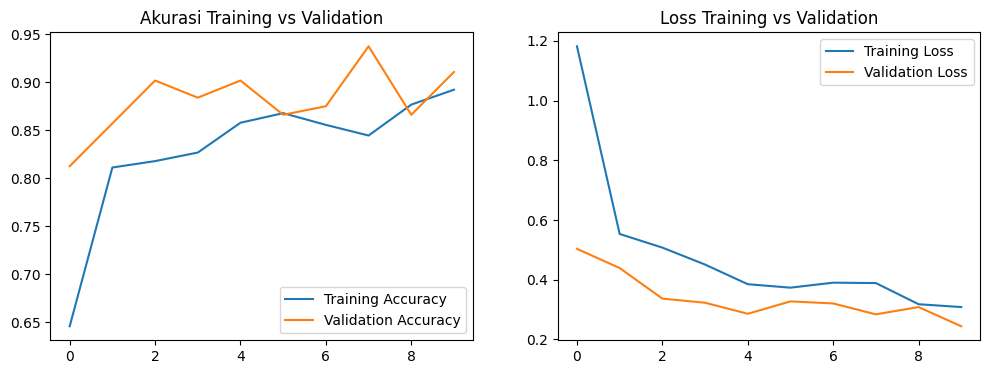

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Akurasi Training vs Validation')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss Training vs Validation')

plt.show()

## Evaluasi pada Test Set
Performa model diuji menggunakan **Test Set**, yaitu data yang belum pernah dilihat model sama sekali selama proses training maupun validasi. Hasil ini menjadi tolak ukur paling objektif terhadap kemampuan generalisasi model.

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Akurasi pada Test Set: {test_acc*100:.2f}%")
print(f"Loss pada Test Set: {test_loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 335ms/step - accuracy: 0.9646 - loss: 0.1820
Akurasi pada Test Set: 96.46%
Loss pada Test Set: 0.1820


## Confusion Matrix & Classification Report
Untuk menganalisis performa model secara lebih mendalam per kelas, kita menampilkan **Confusion Matrix** untuk melihat kelas mana saja yang sering tertukar prediksinya, serta **Classification Report** yang menampilkan nilai *precision*, *recall*, dan *F1-score* untuk masing-masing kelas cuaca.

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 554ms/step


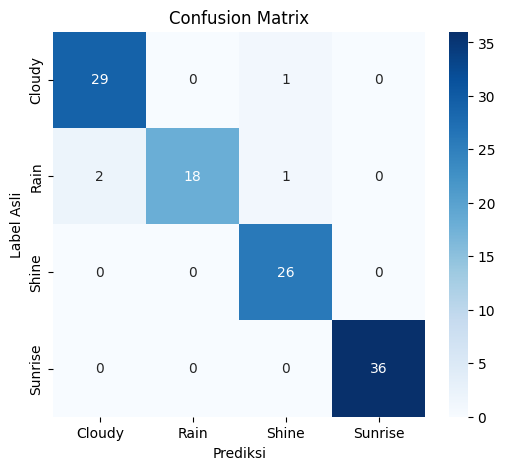

              precision    recall  f1-score   support

      Cloudy       0.94      0.97      0.95        30
        Rain       1.00      0.86      0.92        21
       Shine       0.93      1.00      0.96        26
     Sunrise       1.00      1.00      1.00        36

    accuracy                           0.96       113
   macro avg       0.97      0.96      0.96       113
weighted avg       0.97      0.96      0.96       113



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_generator.classes

class_names = list(labels_map.values())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Prediksi')
plt.ylabel('Label Asli')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## Contoh Hasil Prediksi
Sebagai validasi akhir, kita menampilkan beberapa sampel gambar dari Test Set beserta label asli dan label hasil prediksi model, untuk melihat secara langsung performa model dalam mengenali kondisi cuaca.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


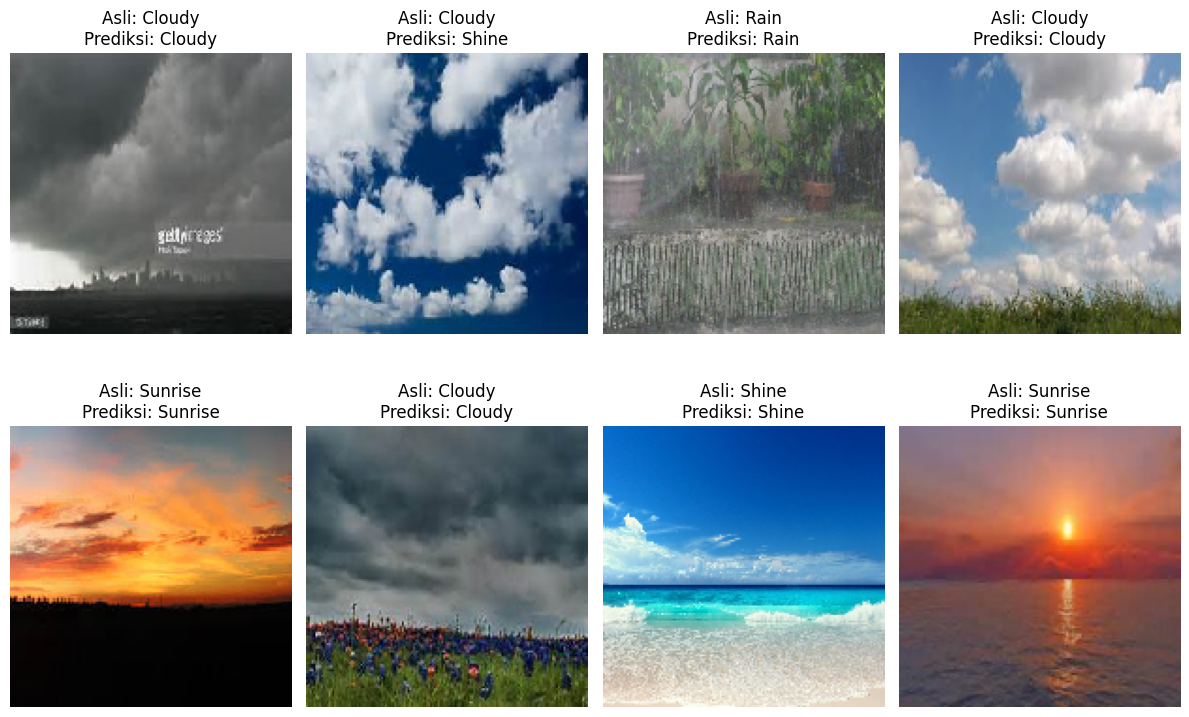

In [ ]:
test_generator.reset()
images, labels = next(test_generator)
preds = model.predict(images)

plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    label_asli = labels_map[np.argmax(labels[i])]
    label_prediksi = labels_map[np.argmax(preds[i])]
    plt.title(f"Asli: {label_asli}\nPrediksi: {label_prediksi}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Langkah 12: Menyimpan Model
Model yang telah dilatih disimpan dalam format `.h5` agar dapat digunakan kembali tanpa perlu melakukan training ulang, sekaligus mempermudah proses deployment ke aplikasi web (Streamlit) pada tahap berikutnya.

In [ ]:
model.save('model_klasifikasi_cuaca.h5')
print("Model berhasil disimpan!")

Model berhasil disimpan!


## Langkah 13: Uji Coba Model dengan Gambar Baru
Untuk memastikan model bekerja dengan baik di luar dataset asli, kita menguji model menggunakan gambar baru yang diunggah secara manual.

In [1]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for nama_file in uploaded.keys():
    img = image.load_img(nama_file, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    label_prediksi = labels_map[np.argmax(pred)]
    confidence = np.max(pred) * 100

    plt.imshow(img)
    plt.title(f"Prediksi: {label_prediksi} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

Saving test_cuaca.jpg to test_cuaca.jpg


NameError: name 'IMG_SIZE' is not defined